# Exploración de datos PAES 2026 — MATE1_MAX

Continuación de `01_exploracion_datos.ipynb` y de `02_exploracion_clec_max.ipynb`. Se replica exactamente el mismo procedimiento aplicado a `CLEC_MAX`, ahora sobre `MATE1_MAX` (puntaje máximo obtenido entre todas las rendiciones de la Prueba de Matemática 1).

> **Nota al margen:** se mantiene el mismo criterio metodológico: describir primero, decidir después. El tratamiento de los valores en cero se documenta pero no se resuelve en este notebook.

## Entorno y carga de datos

In [1]:
# Mismas rutas y misma fuente de datos utilizadas en 01_exploracion_datos.ipynb y 02_exploracion_clec_max.ipynb
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DIRECTORIO_ACTUAL = Path.cwd()
DIRECTORIO_RAIZ = DIRECTORIO_ACTUAL.parent
RAW_DIR = DIRECTORIO_RAIZ / "data" / "raw"

In [2]:
# Carga del conjunto Inscritos y Puntajes (separador ';' y decimal ',', igual que en los notebooks anteriores)
RUTA_INSCRITOS = RAW_DIR / "PAES-2026-Inscritos-Puntajes" / "A_INSCRITOS_PUNTAJES_PAES_2026_PUB_MRUN.csv"

inscritos = pd.read_csv(RUTA_INSCRITOS, sep=";", decimal=",", low_memory=False)
inscritos.shape

(320087, 131)

## Foco de esta entrega: `MATE1_MAX`

Según la ficha de metadatos, `MATE1_MAX` corresponde al puntaje máximo obtenido entre todas las Pruebas de Matemática 1 rendidas, a diferencia de `MATE1_REG_ACTUAL`, que refleja únicamente el resultado del proceso regular 2026.

In [3]:
# Verificamos el tipo de dato antes de cualquier calculo, misma comprobacion que se hizo para CLEC_MAX
MATE1_MAX_col = inscritos["MATE1_MAX"]
MATE1_MAX_col.dtype

dtype('int64')

> **Nota al margen:** al igual que `CLEC_MAX`, `MATE1_MAX` ya viene como `int64`. Esto vuelve a ser indicio de ausencia de nulos (una columna `int64` con NaN habria sido forzada a `float64`), lo cual se confirma explicitamente a continuacion.

## Nulos vs. ceros

In [4]:
# Igual que en CLEC_MAX: se distingue explicitamente entre "no hay dato" (NaN) y "el dato es cero"
n_total = len(inscritos)
n_nulos = MATE1_MAX_col.isna().sum()
n_ceros = (MATE1_MAX_col == 0).sum()
n_validos = (MATE1_MAX_col > 0).sum()

resumen_mate1_max = pd.DataFrame({
    "Cantidad": [n_nulos, n_ceros, n_validos],
    "% del total": [
        round(n_nulos / n_total * 100, 2),
        round(n_ceros / n_total * 100, 2),
        round(n_validos / n_total * 100, 2),
    ]
}, index=["Nulos (NaN)", "En cero", "Puntaje > 0"])

resumen_mate1_max

,Cantidad,% del total
Nulos (NaN),0,0.00
En cero,46817,14.63
Puntaje > 0,273270,85.37


`MATE1_MAX` **no tiene valores nulos** (0,00%). Un **14,63% (46.817 casos)** registra un valor de cero. Al igual que en `CLEC_MAX`, esta prueba es de caracter obligatorio en el proceso de admision, por lo que el mismo cuestionamiento aplica: no es evidente si el cero es un puntaje real o si encubre una no-rendicion.

**Esta pregunta se deja pendiente**, igual que para `CLEC_MAX`.

### Contraste con `MATE1_REG_ACTUAL`

Para dimensionar cuanto "rescata" `MATE1_MAX` frente a la variable de registro actual, se compara contra `MATE1_REG_ACTUAL` (convertida a numerica, ya que en `01_exploracion_datos.ipynb` se detecto como `str`).

In [5]:
# Conversion de MATE1_REG_ACTUAL a numerico, mismo criterio usado en 01_exploracion_datos.ipynb para CLEC_REG_ACTUAL
reg_num = pd.to_numeric(inscritos["MATE1_REG_ACTUAL"], errors="coerce")

# Casos "rescatados": el estudiante no tiene dato en el proceso regular actual (NaN),
# pero SI tiene un puntaje maximo mayor a 0 en otra rendicion
rescatados = ((reg_num.isna()) & (MATE1_MAX_col > 0)).sum()

print("Nulos en MATE1_REG_ACTUAL:", reg_num.isna().sum(), f"({reg_num.isna().sum()/n_total*100:.2f}%)")
print("Ceros en MATE1_REG_ACTUAL:", (reg_num == 0).sum(), f"({(reg_num==0).sum()/n_total*100:.2f}%)")
print("Rescatados por MATE1_MAX: ", rescatados, f"({rescatados/n_total*100:.2f}%)")

Nulos en MATE1_REG_ACTUAL: 19496 (6.09%)
Ceros en MATE1_REG_ACTUAL: 54577 (17.05%)
Rescatados por MATE1_MAX:  18209 (5.69%)

> **Nota al margen:** `MATE1_MAX` rescata un 5,69% de estudiantes que `MATE1_REG_ACTUAL` pierde por nulos — una proporcion casi identica al 5,72% observado para `CLEC_MAX` en el notebook anterior. Esto refuerza la hipotesis del equipo: `MATE1_MAX` es una variable mas "definitiva" que su version de registro actual.

## Estadisticos descriptivos

In [6]:
# Tendencia central y dispersion, mismo bloque que en CLEC_MAX
print("Media:   ", MATE1_MAX_col.mean().round(1))
print("Mediana: ", MATE1_MAX_col.median().round(1))
print("Moda:    ", MATE1_MAX_col.mode().iloc[0], f"(n={n_ceros})")
print("Desv.Est:", MATE1_MAX_col.std().round(1))

Media:    544.9
Mediana:  587.0
Moda:     0 (n=46817)
Desv.Est: 264.5

In [7]:
MATE1_MAX_col.describe().round(1)

count    320087.0
mean        544.9
std         264.5
min           0.0
25%         486.0
50%         587.0
75%         699.0
max        1000.0
Name: MATE1_MAX, dtype: float64

## Distribucion por bandas de puntaje

In [8]:
# Mismas bandas de 100 en 100 puntos usadas para CLEC_MAX, para mantener comparabilidad entre variables
tabla_bandas = inscritos["MATE1_MAX"].value_counts(bins=range(0, 1100, 100), sort=False).reset_index()
tabla_bandas.columns = ["Banda de puntaje", "Observaciones"]
tabla_bandas["Porcentaje"] = (tabla_bandas["Observaciones"] / n_total * 100).round(2)
tabla_bandas

Banda de puntaje,Observaciones,Porcentaje
"(-0.001, 100.0]",46836,14.63
"(100.0, 200.0]",12,0.00
"(200.0, 300.0]",81,0.03
"(300.0, 400.0]",3828,1.20
"(400.0, 500.0]",41712,13.03
"(500.0, 600.0]",82105,25.65
"(600.0, 700.0]",66888,20.90
"(700.0, 800.0]",34396,10.75
"(800.0, 900.0]",25264,7.89
"(900.0, 1000.0]",18965,5.92


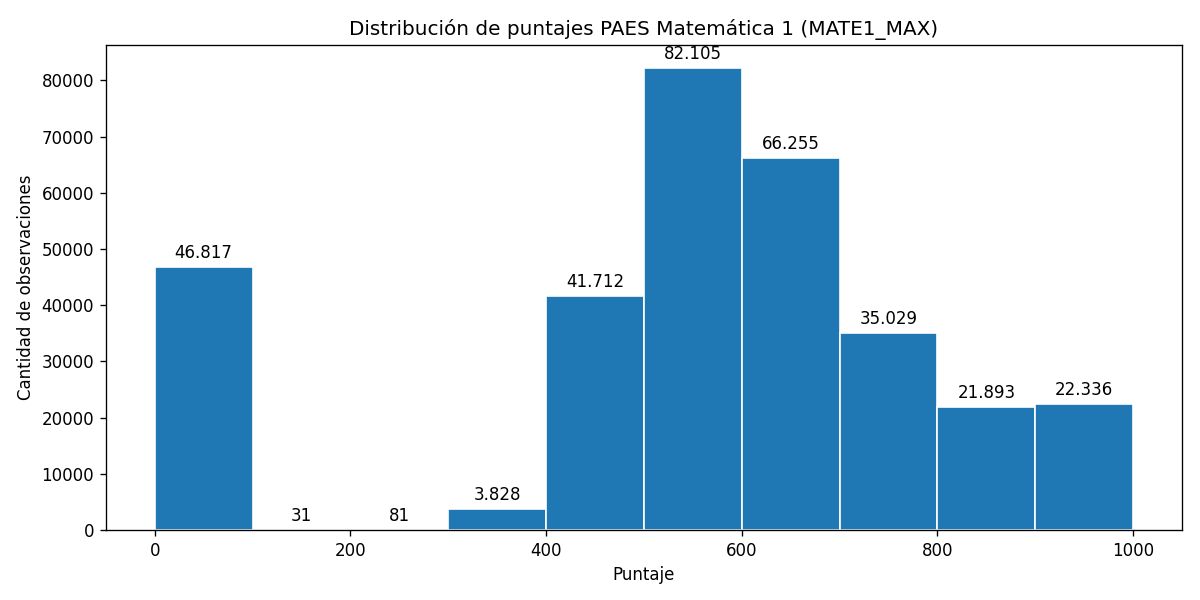

In [9]:
# Histograma con bandas de 100 puntos, mismo formato usado en CLEC_MAX y en 01_exploracion_datos.ipynb
plt.figure(figsize=(10, 5))
conteos, bordes, barras = plt.hist(
    inscritos["MATE1_MAX"],
    bins=range(0, 1100, 100),
    color="#1f77b4",
    edgecolor="white"
)
plt.xlabel("Puntaje Matemática 1")
plt.ylabel("Cantidad de observaciones")
plt.title("Distribución de puntajes PAES Matemática 1 (MATE1_MAX)")
plt.bar_label(
    barras,
    labels=[f"{int(x):,}".replace(",", ".") for x in conteos],
    padding=3
)
plt.show()

## Síntesis y decisión pendiente

- `MATE1_MAX` **no presenta valores nulos** (0,00%).
- **14,63% de las observaciones (46.817 casos)** registra un valor de cero, con el mismo cuestionamiento que en `CLEC_MAX`: no es evidente si es un puntaje real o una no-rendición encubierta.
- `MATE1_MAX` rescata un **5,69%** de casos que `MATE1_REG_ACTUAL` pierde por nulos — cifra casi identica al 5,72% de `CLEC_MAX`, lo que refuerza que ambas variables `_MAX` son mas robustas que sus pares de registro actual.
- El 85,37% restante se distribuye entre 400 y 1000 puntos, con una cola mas larga hacia el tramo alto (900-1000) que la observada en `CLEC_MAX`: 5,92% vs. 0,82%. Esto es coherente con la naturaleza de la prueba (Matematica 1 suele mostrar mayor dispersion en el extremo superior).

**To Do equipo:** mismo criterio pendiente que para `CLEC_MAX` — definir el tratamiento de los valores en cero antes del analisis final. Continua en `04_exploracion_mate2_max.ipynb`, donde la proporcion de ceros es sustancialmente mayor por tratarse de una prueba optativa.